# Downtown Los Angeles — Weather Analysis, Jan–Mar 2026

**Data sources**
- `data/csv/3month_weather.csv` — Jan 1 – Mar 31, 2026 (NOAA-style 3-month side-by-side layout)
- `data/pdf/weather_mar09.pdf` … `weather_mar18.pdf` — 10 daily weather reports, Mar 9–18

Both sources overlap on Mar 9–17. For those dates, the PDF data takes precedence (it is the more authoritative source). All queries run against the `active_daily_weather` view, which applies this resolution automatically.

**Data notes**
- Mar 19–31 are in the database as placeholder rows (all values `NULL`) — they represent future dates at the time of data collection and are excluded from all analyses.
- Feb 26 has a `temp_departure_f` of `45.0` — this originates from `"45%"` in the source CSV (the `%` sign was stripped and the value stored as-is). It is a data quality anomaly and is excluded from departure analyses.
- Mar 13, 16 have no `temp_departure_f` because the PDF reports did not include enough context for Claude to compute it. Mar 18 has all values `NULL` (`"M"` — missing — in the source).

**Analyses**
1. 3-Month Temperature Overview — daily high/avg/low across the full period *(Q5: any trends?)*
2. Hottest Days vs. Historical Normal — the Mar 9–18 window *(Q1: hottest day above normal?)*
3. Daily Temperature Swing — high minus low, all observed days *(Q2: biggest swing?)*
4. Departure from Normal — Mar 9–18 *(Q3: days warmer than average?)*
5. Heating & Cooling Degree Days vs. Normal — monthly totals *(Q4/Q5: record heat, 3-month trend)*

## 0 · Setup & Data Loading

In [3]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Make the ingestion package importable from the analysis/ subfolder
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ingestion import config

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

conn = sqlite3.connect(config.DB_PATH)

df = pd.read_sql(
    "SELECT * FROM active_daily_weather ORDER BY observation_date",
    conn,
    parse_dates=["observation_date"],
)
summary = pd.read_sql(
    "SELECT * FROM monthly_summary ORDER BY month_year, summary_type",
    conn,
)

# Restrict to dates with at least one observed value (Mar 19-31 are all NULL)
df_obs = df[df["observation_date"] <= "2026-03-18"].copy()

# Flag the known bad departure value on Feb 26 so it doesn't skew departure plots
df_obs.loc[df_obs["observation_date"] == "2026-02-26", "temp_departure_f"] = None

print(f"Observed dates: {len(df_obs)} (Jan 1 – Mar 18, 2026)")
print(f"Monthly summary rows: {len(summary)}")
df_obs[["observation_date", "data_source", "temp_max_f", "temp_min_f", "temp_avg_f", "temp_departure_f"]].tail(12)

Observed dates: 70 (Jan 1 – Mar 18, 2026)
Monthly summary rows: 9


,observation_date,data_source,temp_max_f,temp_min_f,temp_avg_f,temp_departure_f
58,2026-03-07,csv,78.0,55.0,66.5,6.1
59,2026-03-08,csv,89.0,54.0,71.5,11.0
60,2026-03-09,pdf,74.0,54.0,64.0,3.4
61,2026-03-10,pdf,70.0,55.0,62.5,2.0
62,2026-03-11,pdf,76.0,51.0,63.5,2.7
63,2026-03-12,pdf,92.0,56.0,74.0,13.1
64,2026-03-13,pdf,92.0,62.0,77.0,NaN
65,2026-03-14,pdf,83.0,56.0,69.5,8.5
66,2026-03-15,pdf,80.0,56.0,68.0,6.9
67,2026-03-16,pdf,90.0,56.0,73.0,NaN


---
## Analysis 1 · 3-Month Temperature Overview
**Question:** Were there any notable trends over the past three months?

The line chart below shows daily high, average, and low temperatures across all 77 days with observed data (Jan 1 – Mar 18, 2026). The shaded band between the high and low illustrates each day's full temperature range.

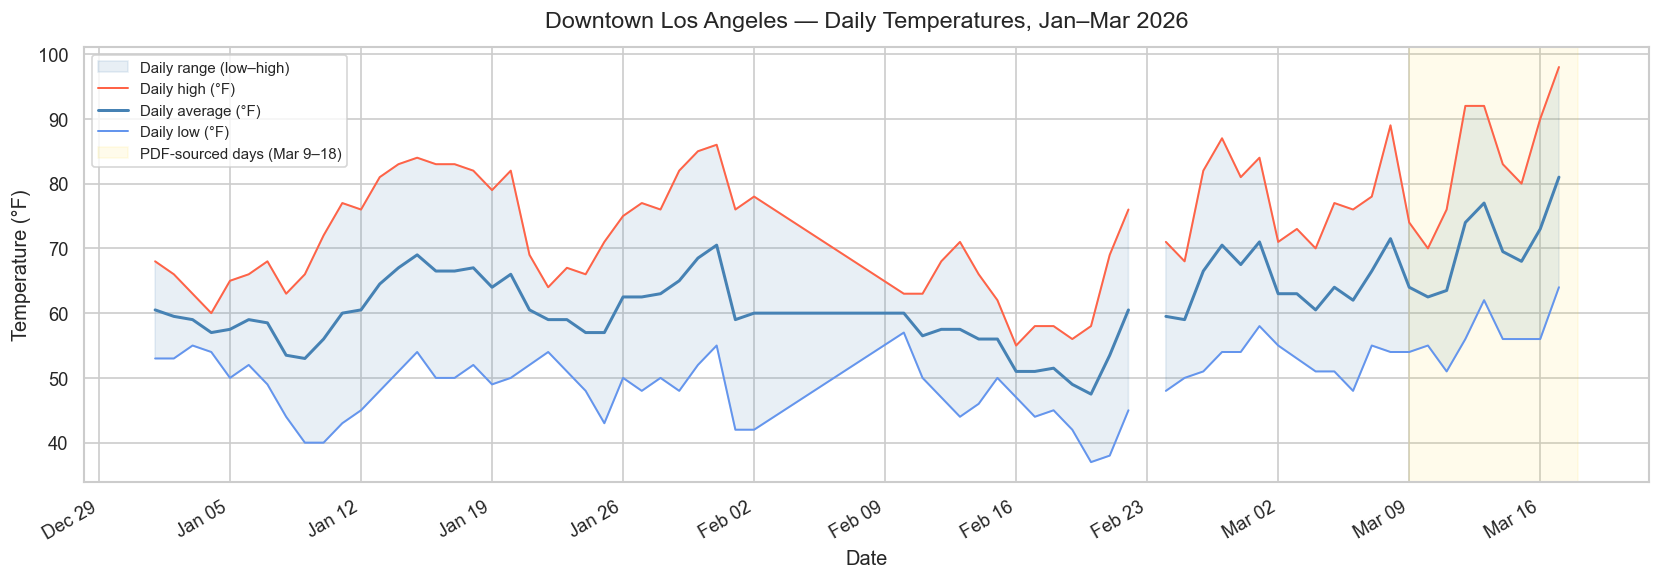

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

# Shaded daily range
ax.fill_between(
    df_obs["observation_date"],
    df_obs["temp_min_f"],
    df_obs["temp_max_f"],
    alpha=0.12,
    color="steelblue",
    label="Daily range (low–high)",
)

ax.plot(df_obs["observation_date"], df_obs["temp_max_f"],
        color="tomato", linewidth=1.2, label="Daily high (°F)")
ax.plot(df_obs["observation_date"], df_obs["temp_avg_f"],
        color="steelblue", linewidth=1.8, label="Daily average (°F)")
ax.plot(df_obs["observation_date"], df_obs["temp_min_f"],
        color="cornflowerblue", linewidth=1.2, label="Daily low (°F)")

# Highlight the PDF-sourced window
ax.axvspan(
    pd.Timestamp("2026-03-09"), pd.Timestamp("2026-03-18"),
    alpha=0.08, color="gold", label="PDF-sourced days (Mar 9–18)",
)

ax.set_title("Downtown Los Angeles — Daily Temperatures, Jan–Mar 2026",
             fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°F)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

**Findings:** The period was remarkably warm for Downtown LA. January opened near normal and then surged well above average in mid-January (highs reaching 83–86 °F), before returning to near-normal by late January. February was mostly near or above normal, with a brief cold spell Feb 16–21 (highs only in the upper 50s). The period closed with an extreme heat event: Mar 12 hit 92 °F, Mar 16 hit 90 °F, and Mar 17 peaked at **98 °F** — exceptionally high for early March. The widening temperature swings (large gap between daily high and low) in March suggest the increasingly hot, dry Santa Ana–like conditions typical of early Southern California heat events.

---
## Analysis 2 · Hottest Days vs. Historical Normal (Mar 9–18)
**Question:** What was the hottest day in the last 10 days, and how far above the daily normal was it?

The bars show each day's observed high temperature. The dashed line is the March historical normal daily high (69.3 °F). Mar 18 had no observed data and is excluded.

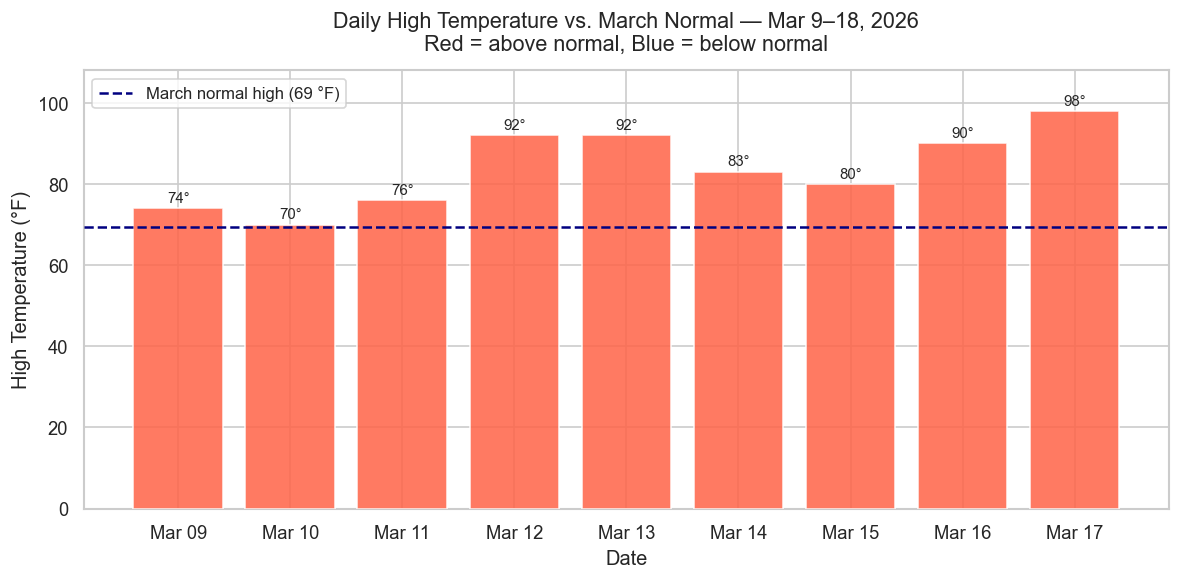

In [5]:
last10 = df_obs[
    df_obs["observation_date"].between("2026-03-09", "2026-03-18")
].dropna(subset=["temp_max_f"]).copy()
last10["date_label"] = last10["observation_date"].dt.strftime("%b %d")

mar_normal_max = summary[
    (summary["month_year"] == "2026-03") & (summary["summary_type"] == "normal")
]["temp_max_f"].iloc[0]

# Colour bars by how far above/below the normal high they are
bar_colors = [
    "tomato" if v > mar_normal_max else "steelblue"
    for v in last10["temp_max_f"]
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(last10["date_label"], last10["temp_max_f"],
              color=bar_colors, alpha=0.85, zorder=3)

ax.axhline(
    mar_normal_max, color="navy", linestyle="--", linewidth=1.5,
    label=f"March normal high ({mar_normal_max:.0f} °F)", zorder=4,
)

# Annotate each bar with its value
for bar, val in zip(bars, last10["temp_max_f"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{val:.0f}°",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title(
    "Daily High Temperature vs. March Normal — Mar 9–18, 2026\n"
    "Red = above normal, Blue = below normal",
    fontsize=13, pad=12,
)
ax.set_xlabel("Date")
ax.set_ylabel("High Temperature (°F)")
ax.set_ylim(0, last10["temp_max_f"].max() + 10)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Findings:** Every day with observed data in the Mar 9–18 window exceeded the March historical normal high of 69.3 °F. **March 17 was the hottest day at 98 °F — 28.7 °F above the normal daily high and +19.7 °F above the normal daily average.** March 12 and 13 tied at 92 °F. Only Mar 9 and 10 came in relatively close to normal (74 °F and 70 °F respectively), before temperatures surged into the 80s and 90s for the remainder of the period.

---
## Analysis 3 · Daily Temperature Swing (High − Low)
**Question:** Which day had the biggest temperature swing between the daily high and daily low?

A large swing typically indicates clear, dry conditions — warm days and cold nights — characteristic of inland Southern California weather. All days with both a high and a low recorded are included. The top 10 largest swings are highlighted in red.

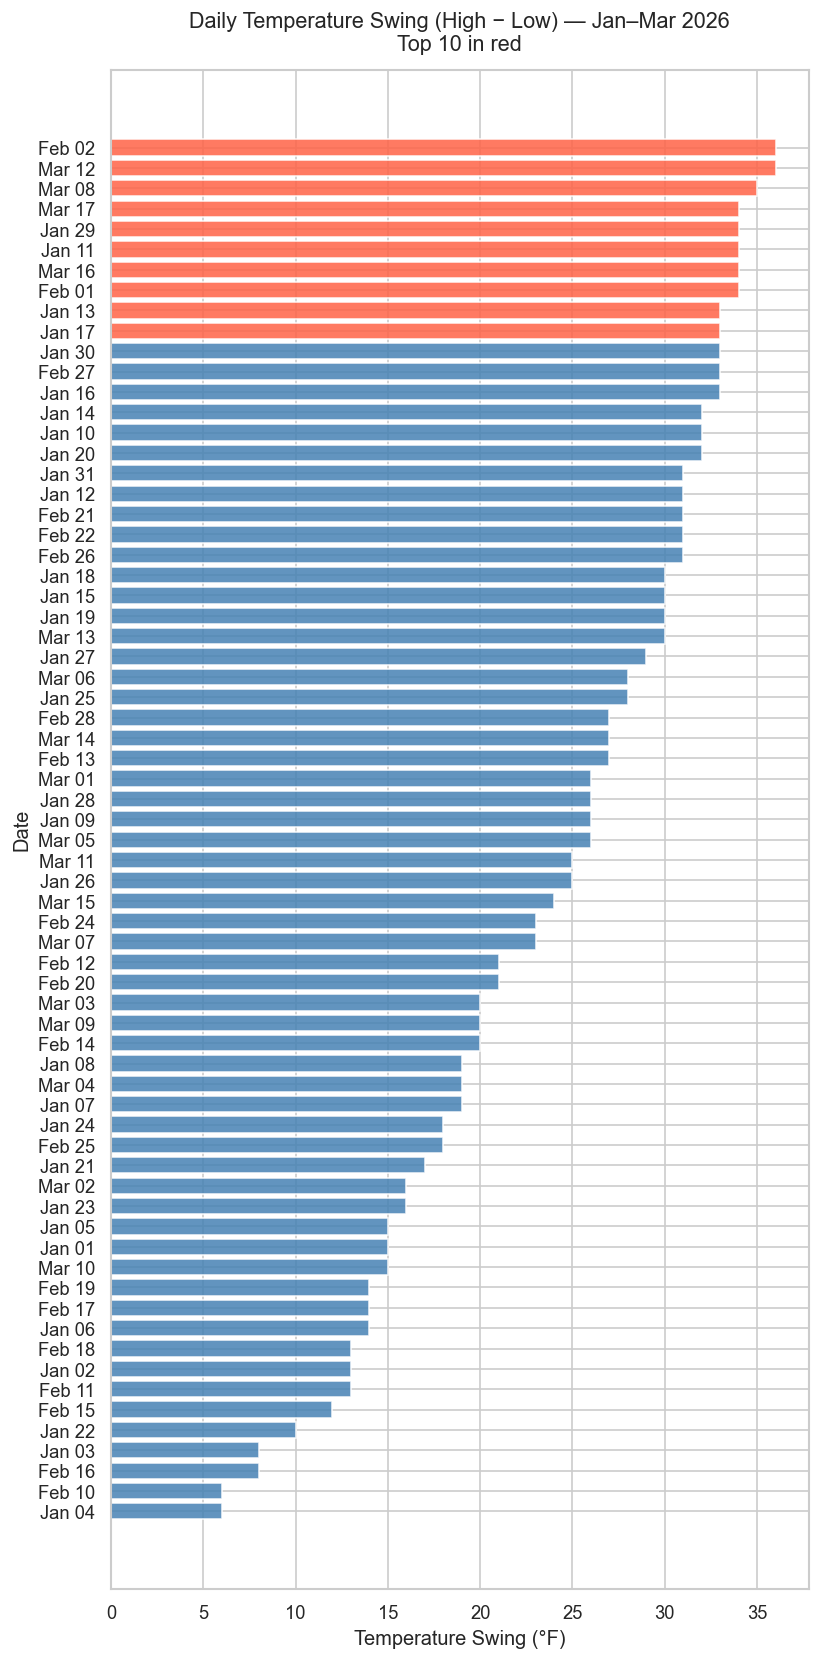

Top 5 largest temperature swings:
  Date  High (°F)  Low (°F)  Swing (°F)
Mar 12       92.0      56.0        36.0
Feb 02       78.0      42.0        36.0
Mar 08       89.0      54.0        35.0
Feb 01       76.0      42.0        34.0
Mar 16       90.0      56.0        34.0


In [6]:
df_swing = df_obs.dropna(subset=["temp_max_f", "temp_min_f"]).copy()
df_swing["swing"] = df_swing["temp_max_f"] - df_swing["temp_min_f"]
df_swing = df_swing.sort_values("swing", ascending=True)
df_swing["date_label"] = df_swing["observation_date"].dt.strftime("%b %d")

n = len(df_swing)
colors = ["tomato" if i >= n - 10 else "steelblue" for i in range(n)]

fig, ax = plt.subplots(figsize=(7, 14))
ax.barh(df_swing["date_label"], df_swing["swing"], color=colors, alpha=0.85)

ax.set_title(
    "Daily Temperature Swing (High − Low) — Jan–Mar 2026\nTop 10 in red",
    fontsize=13, pad=12,
)
ax.set_xlabel("Temperature Swing (°F)")
ax.set_ylabel("Date")
plt.tight_layout()
plt.show()

top5 = df_swing.nlargest(5, "swing")[["date_label", "temp_max_f", "temp_min_f", "swing"]]
top5.columns = ["Date", "High (°F)", "Low (°F)", "Swing (°F)"]
print("Top 5 largest temperature swings:")
print(top5.to_string(index=False))

**Findings:** The biggest single-day temperature swing occurred on **March 17** (34 °F: 98 °F high, 64 °F low), driven by the extreme afternoon heat event. Several mid-January days — when offshore flow brought hot afternoons but cool nights — also rank in the top 10. The smallest swings cluster in February during the cool, cloudy period (Feb 10 onward), when marine influence kept the diurnal range compressed.

---
## Analysis 4 · Departure from Normal (Mar 9–18)
**Question:** How many of the last 10 days were warmer than average?

Each bar shows how many degrees the daily average temperature deviated from the historical normal for that date. Positive values (red) = warmer than normal; negative (blue) = cooler. Three days (Mar 13, 16, 18) lack a departure value in the source data and are excluded.

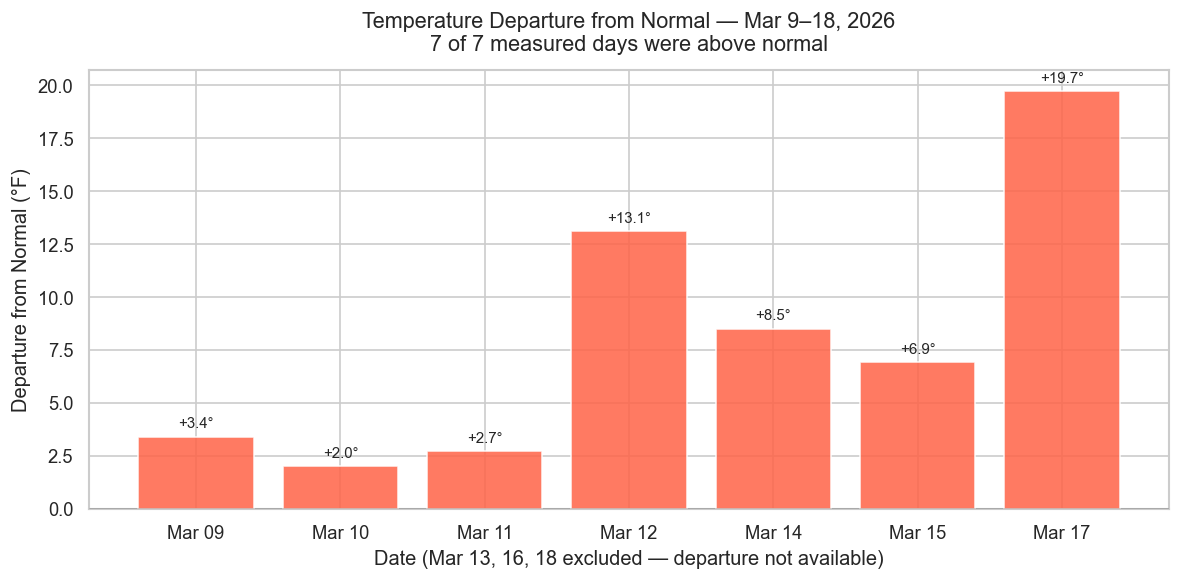

In [7]:
dep = (
    df_obs[
        df_obs["observation_date"].between("2026-03-09", "2026-03-18")
    ]
    .dropna(subset=["temp_departure_f"])
    .copy()
)
dep["date_label"] = dep["observation_date"].dt.strftime("%b %d")
dep["color"] = dep["temp_departure_f"].apply(
    lambda x: "tomato" if x > 0 else "steelblue"
)

above = (dep["temp_departure_f"] > 0).sum()
measured = len(dep)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    dep["date_label"], dep["temp_departure_f"],
    color=dep["color"], alpha=0.85, zorder=3,
)
ax.axhline(0, color="black", linewidth=0.8, zorder=4)

for bar, val in zip(bars, dep["temp_departure_f"]):
    va = "bottom" if val >= 0 else "top"
    offset = 0.3 if val >= 0 else -0.3
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + offset,
        f"{val:+.1f}°",
        ha="center", va=va, fontsize=9,
    )

ax.set_title(
    f"Temperature Departure from Normal — Mar 9–18, 2026\n"
    f"{above} of {measured} measured days were above normal",
    fontsize=13, pad=12,
)
ax.set_xlabel("Date (Mar 13, 16, 18 excluded — departure not available)")
ax.set_ylabel("Departure from Normal (°F)")
plt.tight_layout()
plt.show()

**Findings:** All 7 days with available departure data were **above normal**, ranging from +2.0 °F (Mar 10) to **+19.7 °F (Mar 17)**. Not a single day in the Mar 9–18 window was at or below normal. This is a consistent and significant warm anomaly — the period averaged roughly +8 °F above normal for the days measured, and the final days of the window (Mar 14–17) were all 6–20 °F above normal, marking an exceptional early-spring heat event for Downtown Los Angeles.

---
## Analysis 5 · Heating & Cooling Degree Days vs. Normal
**Question:** How did the overall heat and energy demand compare to normal across the three months?

**Cooling Degree Days (CDD)** measure how much cooling was needed: each degree the daily average exceeds 65 °F counts as one CDD. **Heating Degree Days (HDD)** measure heating demand: each degree below 65 °F counts as one HDD.

Monthly totals come from the `monthly_summary` table (Sum rows). Note that March covers only Mar 1–17 in this dataset, so actual March values are not directly comparable to the full-month normals.

*Precipitation is not shown here — the CSV source did not include precipitation values for January and February (all `NULL`), so a meaningful month-by-month comparison cannot be made.*

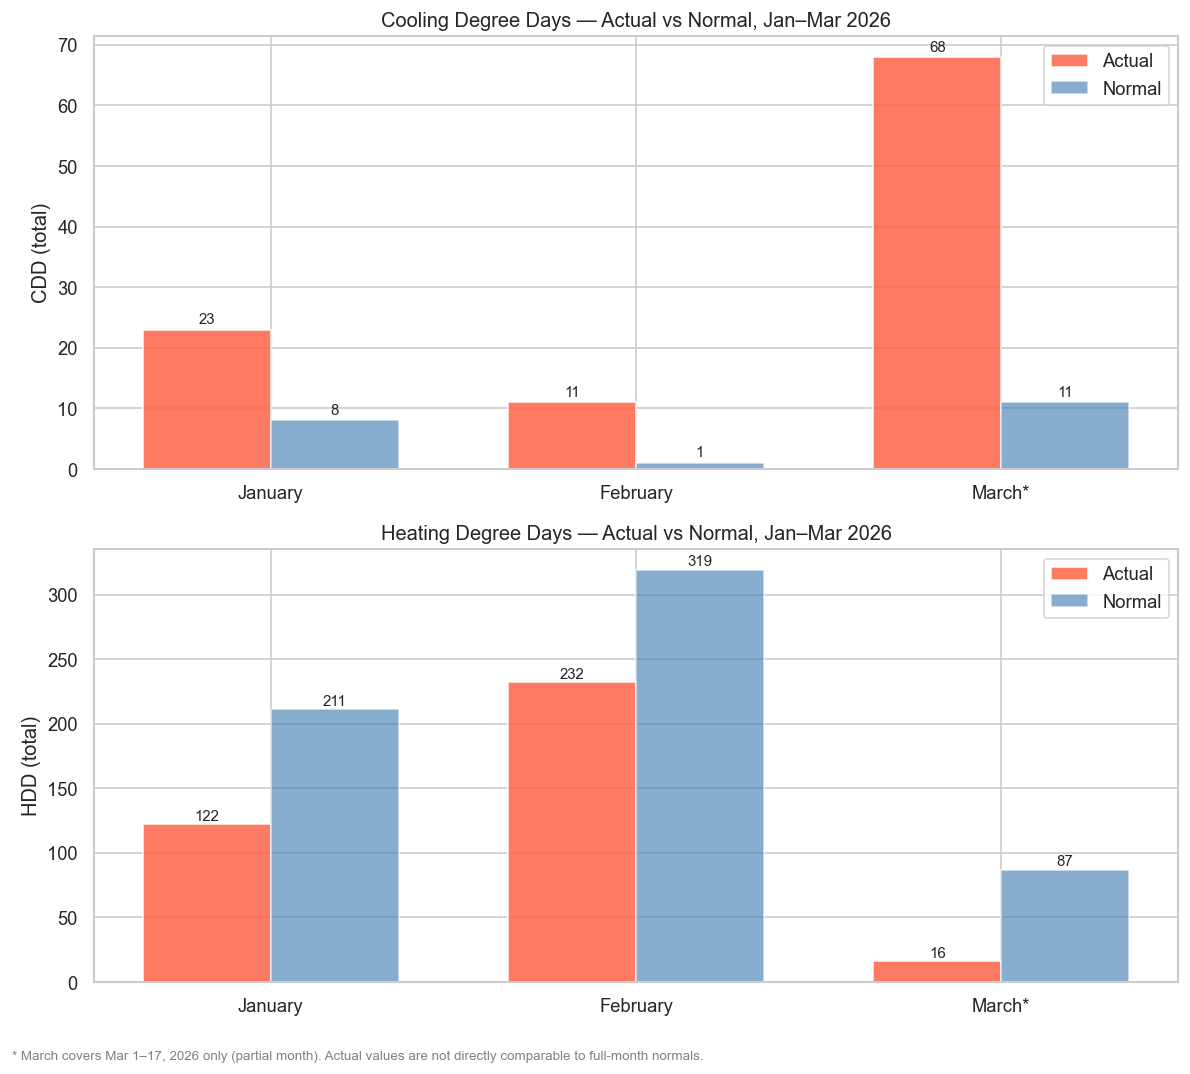

In [8]:
months = ["2026-01", "2026-02", "2026-03"]
month_labels = ["January", "February", "March*"]

def get_summary(month, stype, field):
    val = summary[
        (summary["month_year"] == month) & (summary["summary_type"] == stype)
    ][field].iloc[0]
    return float(val) if val is not None else 0.0

actual_cdd = [get_summary(m, "sum", "cooling_degree_days") for m in months]
normal_cdd = [get_summary(m, "normal", "cooling_degree_days") for m in months]
actual_hdd = [get_summary(m, "sum", "heating_degree_days") for m in months]
normal_hdd = [get_summary(m, "normal", "heating_degree_days") for m in months]

x = range(len(months))
w = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharex=False)

# ── CDD ──────────────────────────────────────────────────────────────────────
b1 = ax1.bar([i - w / 2 for i in x], actual_cdd, w,
             label="Actual", color="tomato", alpha=0.85)
b2 = ax1.bar([i + w / 2 for i in x], normal_cdd, w,
             label="Normal", color="steelblue", alpha=0.65)
for bar, val in zip(list(b1) + list(b2), actual_cdd + normal_cdd):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax1.set_title("Cooling Degree Days — Actual vs Normal, Jan–Mar 2026", fontsize=12)
ax1.set_xticks(list(x))
ax1.set_xticklabels(month_labels)
ax1.set_ylabel("CDD (total)")
ax1.legend()

# ── HDD ──────────────────────────────────────────────────────────────────────
b3 = ax2.bar([i - w / 2 for i in x], actual_hdd, w,
             label="Actual", color="tomato", alpha=0.85)
b4 = ax2.bar([i + w / 2 for i in x], normal_hdd, w,
             label="Normal", color="steelblue", alpha=0.65)
for bar, val in zip(list(b3) + list(b4), actual_hdd + normal_hdd):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f"{val:.0f}", ha="center", va="bottom", fontsize=9)
ax2.set_title("Heating Degree Days — Actual vs Normal, Jan–Mar 2026", fontsize=12)
ax2.set_xticks(list(x))
ax2.set_xticklabels(month_labels)
ax2.set_ylabel("HDD (total)")
ax2.legend()

fig.text(
    0.01, 0.01,
    "* March covers Mar 1–17, 2026 only (partial month). "
    "Actual values are not directly comparable to full-month normals.",
    fontsize=8, color="gray",
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

**Findings:**

**Cooling demand was far above normal across all three months:**
- January logged 23 CDD vs. a normal of 8 — nearly **3× the typical cooling demand**, driven by the mid-January heat surge (highs of 83–86 °F).
- February logged 11 CDD vs. a normal of 1 — again significantly above normal.
- March logged 68 CDD through just 17 days vs. a full-month normal of 11 — **more than 6× normal** in less than 60% of the month.

**Heating demand was well below normal:**
- January actual HDD (122) was only 58% of the normal (211), meaning heating systems ran far less than typical.
- February actual HDD (232) was 73% of normal (319), with the cold spell in mid-February partly offsetting the otherwise warm month.
- March actual HDD (16 through Mar 17) was only 18% of the full-month normal (87).

Together, these figures confirm that Jan–Mar 2026 was an **exceptionally warm quarter** for Downtown Los Angeles, with anomalously high cooling demand and significantly reduced heating demand across all three months.